In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# # Optional: make plots a little cleaner in Jupyter
# plt.rcParams["figure.figsize"] = (8, 6)
# plt.rcParams["axes.grid"] = True

In [2]:
# Option 1: use the folder the notebook is being run from
BASE_DIR = Path.cwd()

# Option 2: use the full folder path instead
# BASE_DIR = Path("/workspaces/LPR_redux/LPR_pycap_opt/notebooks")

depletion_files = {
    "Baseline": "depletion_q_baseline_0.0_1.0_0.2_tradeoff.csv",
    "T -10%": "depletion_q_Tmin10per_0.0_1.0_0.2_tradeoff.csv",
    "T +10%": "depletion_q_Tplus10per_0.0_1.0_0.2_tradeoff.csv",
}

fish_ag_files = {
    "Baseline": "fish_dollars_baseline_0.0_1.0_0.2_tradeoff.csv",
    "T -10%": "fish_dollars_Tmin10per_0.0_1.0_0.2_tradeoff.csv",
    "T +10%": "fish_dollars_Tplus10per_0.0_1.0_0.2_tradeoff.csv",
}

print("Base directory:")
print(BASE_DIR)

Base directory:
/workspaces/LPR_redux/LPR_pycap_opt/notebooks


In [3]:
def load_csvs(file_dict, base_dir):
    data = {}

    for label, filename in file_dict.items():
        file_path = base_dir / filename

        if not file_path.exists():
            raise FileNotFoundError(f"Could not find file: {file_path}")

        df = pd.read_csv(file_path)

        # Drop the extra index-like column if it exists
        if "Unnamed: 0" in df.columns:
            df = df.drop(columns=["Unnamed: 0"])

        data[label] = df

    return data

In [4]:
depletion_data = load_csvs(depletion_files, BASE_DIR)
fish_ag_data = load_csvs(fish_ag_files, BASE_DIR)

print("Loaded depletion files:")
for name, df in depletion_data.items():
    print(f"  {name}: {df.shape}")

print("\nLoaded fish/ag files:")
for name, df in fish_ag_data.items():
    print(f"  {name}: {df.shape}")

Loaded depletion files:
  Baseline: (179, 3)
  T -10%: (181, 3)
  T +10%: (177, 3)

Loaded fish/ag files:
  Baseline: (125, 3)
  T -10%: (108, 3)
  T +10%: (125, 3)


In [5]:
print("Depletion file columns:")
for name, df in depletion_data.items():
    print(f"{name}: {list(df.columns)}")

print("\nFish/Ag file columns:")
for name, df in fish_ag_data.items():
    print(f"{name}: {list(df.columns)}")

Depletion file columns:
Baseline: ['Total Pumping (cfs)', 'Depletion (cfs)', 'member']
T -10%: ['Total Pumping (cfs)', 'Depletion (cfs)', 'member']
T +10%: ['Total Pumping (cfs)', 'Depletion (cfs)', 'member']

Fish/Ag file columns:
Baseline: ['Trout Likelihood (%)', 'Total Agriculture Receipts ($)', 'member']
T -10%: ['Trout Likelihood (%)', 'Total Agriculture Receipts ($)', 'member']
T +10%: ['Trout Likelihood (%)', 'Total Agriculture Receipts ($)', 'member']


In [6]:
print("Baseline depletion preview:")
display(depletion_data["Baseline"].head())

print("Baseline fish/ag preview:")
display(fish_ag_data["Baseline"].head())

Baseline depletion preview:


,Total Pumping (cfs),Depletion (cfs),member
0,10.224827,4.89771,10
1,3.547266,2.16882,gen=49_member=1825_pso
2,10.124990,4.82867,12
3,9.952275,4.69714,36
4,6.882626,3.26559,gen=43_member=1604_pso


Baseline fish/ag preview:


,Trout Likelihood (%),Total Agriculture Receipts ($),member
0,0.534656,12389600.0,9
1,0.552279,12366200.0,20
2,0.543042,12372100.0,16
3,0.572764,12303400.0,gen=47_member=1212_pso
4,0.683598,11901700.0,gen=34_member=878_pso


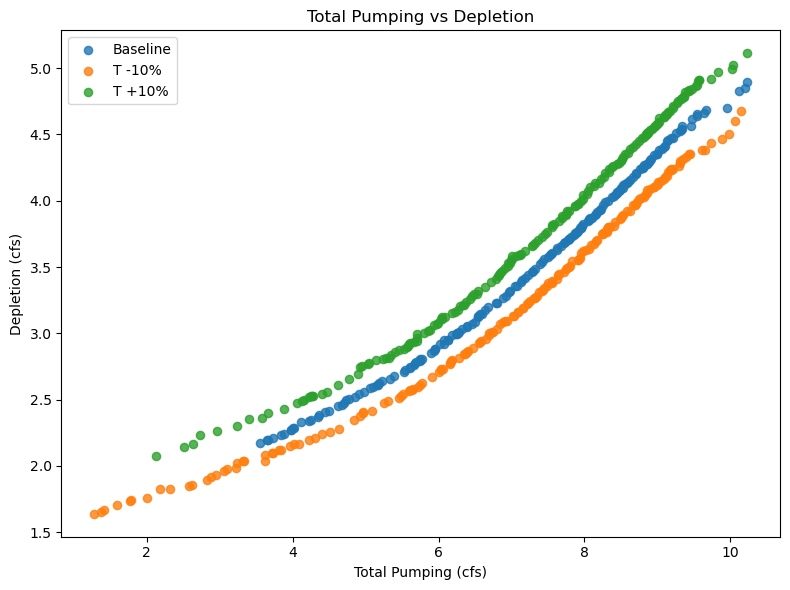

In [7]:
plt.figure(figsize=(8, 6))

for label, df in depletion_data.items():
    plt.scatter(
        df["Total Pumping (cfs)"],
        df["Depletion (cfs)"],
        label=label,
        alpha=0.8,
        s=35
    )

plt.xlabel("Total Pumping (cfs)")
plt.ylabel("Depletion (cfs)")
plt.title("Total Pumping vs Depletion")
plt.legend()
plt.tight_layout()
plt.show()

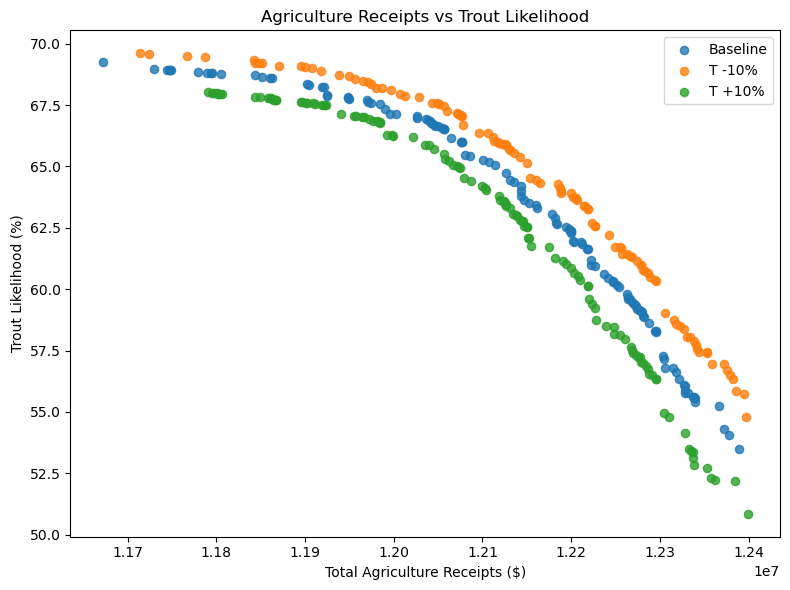

In [8]:
plt.figure(figsize=(8, 6))

for label, df in fish_ag_data.items():
    trout_percent = df["Trout Likelihood (%)"] * 100

    plt.scatter(
        df["Total Agriculture Receipts ($)"],
        trout_percent,
        label=label,
        alpha=0.8,
        s=35
    )

plt.xlabel("Total Agriculture Receipts ($)")
plt.ylabel("Trout Likelihood (%)")
plt.title("Agriculture Receipts vs Trout Likelihood")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# # Save plot 1: Total Pumping vs Depletion
# plt.figure(figsize=(8, 6))

# for label, df in depletion_data.items():
#     plt.scatter(
#         df["Total Pumping (cfs)"],
#         df["Depletion (cfs)"],
#         label=label,
#         alpha=0.8,
#         s=35
#     )

# plt.xlabel("Total Pumping (cfs)")
# plt.ylabel("Depletion (cfs)")
# plt.title("Total Pumping vs Depletion")
# plt.legend()
# plt.tight_layout()
# plt.savefig(BASE_DIR / "total_pumping_vs_depletion.png", dpi=300, bbox_inches="tight")
# plt.show()

# # Save plot 2: Ag vs Fish
# plt.figure(figsize=(8, 6))

# for label, df in fish_ag_data.items():
#     plt.scatter(
#         df["Total Agriculture Receipts ($)"],
#         df["Trout Likelihood (%)"],
#         label=label,
#         alpha=0.8,
#         s=35
#     )

# plt.xlabel("Total Agriculture Receipts ($)")
# plt.ylabel("Trout Likelihood")
# plt.title("Agriculture Receipts vs Trout Likelihood")
# plt.legend()
# plt.tight_layout()
# plt.savefig(BASE_DIR / "ag_vs_fish.png", dpi=300, bbox_inches="tight")
# plt.show()

# print("Saved:")
# print(BASE_DIR / "total_pumping_vs_depletion.png")
# print(BASE_DIR / "ag_vs_fish.png")

In [10]:
# def plot_depletion_tradeoff(data_dict):
#     plt.figure(figsize=(8, 6))

#     for label, df in data_dict.items():
#         plt.scatter(
#             df["Total Pumping (cfs)"],
#             df["Depletion (cfs)"],
#             label=label,
#             alpha=0.8,
#             s=35
#         )

#     plt.xlabel("Total Pumping (cfs)")
#     plt.ylabel("Depletion (cfs)")
#     plt.title("Total Pumping vs Depletion")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()


# def plot_fish_ag_tradeoff(data_dict, convert_to_percent=False):
#     plt.figure(figsize=(8, 6))

#     for label, df in data_dict.items():
#         y = df["Trout Likelihood (%)"] * 100 if convert_to_percent else df["Trout Likelihood (%)"]

#         plt.scatter(
#             df["Total Agriculture Receipts ($)"],
#             y,
#             label=label,
#             alpha=0.8,
#             s=35
#         )

#     plt.xlabel("Total Agriculture Receipts ($)")
#     plt.ylabel("Trout Likelihood (%)" if convert_to_percent else "Trout Likelihood")
#     plt.title("Agriculture Receipts vs Trout Likelihood")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

In [11]:
# plot_depletion_tradeoff(depletion_data)
# plot_fish_ag_tradeoff(fish_ag_data, convert_to_percent=False)